# [Test Run] Standalone HydroMT-SFINCS Direct Rainfall: DAS 101 (RP100)
Kernel: **HydroMT-SFINCS** (`env-sfincs`)

This notebook is an isolated trial run configured specifically for **DAS Cluster 101** under a **100-year design storm (RP100)**.

### Model Specifications for this Run:
- **Target Cluster:** `DAS_101` (Area $\approx 968\text{ km}^2$)
- **Storm Forcing:** `rainfall_rp100_hourly.nc` (Direct Rainfall-on-Grid)
- **Computational Mesh:** $40\text{ m}$ regular grid (EPSG:32747)
- **Subgrid Bathymetry:** $10\text{ m}$ FABDEM ($4\times 4$ sub-pixels per cell)
- **Infiltration Scheme:** Spatially distributed $K_{sat}$ Infiltration Map
- **Output Maps:** $10\text{ m}$ Downscaled Flood Depth, Fuzzy Large Flood Hazard Index (0-1), and Perka BNPB No. 2/2012 Hazard Classification


---  
## 📌 USER CONFIGURATION CONTROL PANEL (Modify Here Only)

> **GUIDELINE FOR TEAM MEMBERS:**  
> You **ONLY need to adjust the variables in the cell below**. All subsequent pipeline steps (Grid Building, Rainfall Forcing, SFINCS Simulation, 10m Downscaling, and Plotting) will automatically adapt.
>
> ### Examples of Common Scenarios:
>
> * **Scenario A: Process a Single Cluster with a Single Return Period (e.g. DAS 102, RP50)**
>   ```python
>   SELECTED_CLUSTERS = ["DAS_101"]
>   SELECTED_RPS = ["rp50"]
>   ```
> * **Scenario B: Process a Single Cluster for ALL Return Periods (e.g. DAS 101, RP2 to RP100)**
>   ```python
>   SELECTED_CLUSTERS = ["DAS_101"]
>   SELECTED_RPS = ["rp2", "rp5", "rp10", "rp25", "rp50", "rp100"]
>   ```
> * **Scenario C: Batch Process ALL 14 Clusters for a 100-Year Flood (RP100)**
>   ```python
>   SELECTED_CLUSTERS = ALL_AVAILABLE_DAS  # or ["DAS_101", "DAS_102", ...]
>   SELECTED_RPS = ["rp100"]
>   ```
> * **Scenario D: Batch Process the Entire Province (ALL 14 Clusters × ALL 6 RPs)**
>   ```python
>   SELECTED_CLUSTERS = ALL_AVAILABLE_DAS
>   SELECTED_RPS = ALL_AVAILABLE_RPS
>   ```

In [1]:
# ==============================================================================
# 1. TARGET DAS CLUSTER AND RETURN PERIOD (TRIAL RUN)
# ==============================================================================
SELECTED_CLUSTERS = ["DAS_101"]
SELECTED_RPS = ["rp100"]

# ==============================================================================
# 2. OPTIONAL BWS INFRASTRUCTURE / SURVEY DATA (None for baseline trial)
#    See specifications in: docs/BWS_DATA_CONTRACT.md
# ==============================================================================
BWS_LEVEES_GPKG = None        # e.g., "data_raw/bws/tanggul_sungai.gpkg"
BWS_GAUGES_GPKG = None        # e.g., "data_raw/bws/pos_awlr.gpkg"
BWS_INFLOW_HYDROGRAPHS = None # e.g., "data_raw/bws/debit_inflow.csv"

# ==============================================================================
# 3. OUTPUT & CONFIG DIRECTORIES
# ==============================================================================
OUTPUT_MODELS_DIR = "models_sfincs_standalone"
OUTPUT_MAPS_DIR = "outputs_standalone"
CONFIG_FILE = "configs/sfincs_standalone_build.yml"
DATA_CATALOG_FILE = "data_catalog_sfincs.yml"

print(f"🎯 Active Target Clusters : {SELECTED_CLUSTERS}")
print(f"🎯 Active Return Periods  : {SELECTED_RPS}")
print(f"📂 Models Directory       : {OUTPUT_MODELS_DIR}")
print(f"🗺️ Hazard Maps Directory   : {OUTPUT_MAPS_DIR}")


🎯 Active Target Clusters : ['DAS_101']
🎯 Active Return Periods  : ['rp100']
📂 Models Directory       : models_sfincs_standalone
🗺️ Hazard Maps Directory   : outputs_standalone


---  
## 1. Environment & Data Verification

In [2]:
# Automatically set working directory to project root
from pathlib import Path
import os, sys
project_root = Path.cwd()
while not (project_root / 'data').exists() and project_root.parent != project_root:
    project_root = project_root.parent
os.chdir(project_root)
if str(project_root / 'scripts') not in sys.path:
    sys.path.insert(0, str(project_root / 'scripts'))

import sys
import os
from pathlib import Path
import pyproj

# Add local scripts directory to path
if "scripts" not in sys.path:
    sys.path.insert(0, "scripts")

# Fix PROJ and GDAL paths dynamically for active Python environment
site_packages = Path(sys.prefix) / 'Lib' / 'site-packages'
proj_dir = (site_packages / 'rasterio' / 'proj_data').resolve()
gdal_dir = (site_packages / 'rasterio' / 'gdal_data').resolve()
if proj_dir.exists():
    os.environ['PROJ_DATA'] = str(proj_dir)
    os.environ['PROJ_LIB'] = str(proj_dir)
    pyproj.datadir.set_data_dir(str(proj_dir))
if gdal_dir.exists():
    os.environ['GDAL_DATA'] = str(gdal_dir)
# Fix PROJ and GDAL paths dynamically for active Python environment
site_packages = Path(sys.prefix) / 'Lib' / 'site-packages'
proj_dir = (site_packages / 'rasterio' / 'proj_data').resolve()
gdal_dir = (site_packages / 'rasterio' / 'gdal_data').resolve()
if proj_dir.exists():
    os.environ['PROJ_DATA'] = str(proj_dir)
    os.environ['PROJ_LIB'] = str(proj_dir)
    pyproj.datadir.set_data_dir(str(proj_dir))
if gdal_dir.exists():
    os.environ['GDAL_DATA'] = str(gdal_dir)
import sfincs_standalone_pipeline
import importlib
importlib.reload(sfincs_standalone_pipeline)
from sfincs_standalone_pipeline import (
    build_sfincs_standalone,
    prepare_sfincs_direct_rain_forcing,
    run_sfincs_model,
    postprocess_sfincs_hazard,
    create_sfincs_flood_animation,
)

print("Environment initialized and Standalone SFINCS pipeline loaded successfully!")

d:\Project\sumbar_flood_hazard\env-sfincs\Lib\site-packages\tqdm\auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


Environment initialized and Standalone SFINCS pipeline loaded successfully!


---  
## 2. Step 1 — Build SFINCS Base Grids (40m Mesh + 10m Subgrid)

Constructs the 2D computational domain, extracts 10m subgrid tables from FABDEM, maps surface roughness from RBI Land Cover, and applies authoritative soil infiltration capacity from **Kementan Soil Texture x RBI Land Cover** (`soil_infiltration_sumbar`).

In [3]:
for das_id in SELECTED_CLUSTERS:
    print(f"\n==================== [{das_id}] BUILDING BASE SFINCS MESH ====================")
    build_sfincs_standalone(
        das_id=das_id,
        output_dir=OUTPUT_MODELS_DIR,
        config_fn=CONFIG_FILE,
        data_catalog_fn=DATA_CATALOG_FILE,
        bws_structures_gpkg=BWS_LEVEES_GPKG,
        bws_gauges_gpkg=BWS_GAUGES_GPKG,
    )


==================== [DAS_101] BUILDING BASE SFINCS MESH ====================
[DAS_101] Preparing optimized spatial data chip...
[DAS_101] Building standalone SFINCS base model at models_sfincs_standalone\DAS_101...
[DAS_101] Base model build completed successfully.


---  
## 3. Step 2 — Apply Direct Rainfall-on-Grid Forcing

Applies the hourly gridded NetCDF precipitation arrays (`rainfall_<rp>.nc`) across all 2D cells.

In [4]:
for das_id in SELECTED_CLUSTERS:
    print(f"\n==================== [{das_id}] PREPARING FORCINGS FOR {SELECTED_RPS} ====================")
    prepare_sfincs_direct_rain_forcing(
        das_id=das_id,
        return_periods=SELECTED_RPS,
        base_model_dir=OUTPUT_MODELS_DIR,
        data_catalog_fn=DATA_CATALOG_FILE,
        bws_inflow_hydrographs=BWS_INFLOW_HYDROGRAPHS,
    )


==================== [DAS_101] PREPARING FORCINGS FOR ['rp100'] ====================
[DAS_101][rp100] Generating direct rainfall model configuration at models_sfincs_standalone\DAS_101_rp100...
[DAS_101][rp100] Ready for simulation at models_sfincs_standalone\DAS_101_rp100.


---  
## 4. Step 3 — Run SFINCS Hydrodynamic Simulation Engine

Executes the 2D hydrodynamic solver (automatic detection of native Windows `sfincs.exe` or `deltares/sfincs-cpu` Docker).

In [5]:
for das_id in SELECTED_CLUSTERS:
    for rp in SELECTED_RPS:
        print(f"\n==================== [{das_id}][{rp}] EXECUTING HYDRODYNAMIC SIMULATION ====================")
        run_sfincs_model(
            das_id=das_id,
            rp=rp,
            base_model_dir=OUTPUT_MODELS_DIR,
        )


==================== [DAS_101][rp100] EXECUTING HYDRODYNAMIC SIMULATION ====================
[DAS_101][rp100] Running SFINCS hydrodynamic engine (Logging to models_sfincs_standalone\DAS_101_rp100\sfincs_run.log)...


[DAS_101][rp100] SFINCS Simulation: 100%|██████████| 100% [1:55:58<00:00, 69.59s/%]

[DAS_101][rp100] Simulation finished successfully.


---
## 5. Step 4 — Downscale Depth to 10m, Compute Fuzzy Large for Flood Hazard Index & Flood Hazard Classification

Downscales SFINCS water levels to high-resolution FABDEM (10m), calculates the **Flood Hazard Index (0-1)** via **Fuzzy Large Membership** (Midpoint: `1.125`, Spread: `1.75`), and classifies into **BNPB Perka No. 2/2012** hazard levels (`Low <= 0.333`, `Medium 0.333 - 0.666`, `High > 0.666`).


In [6]:
for das_id in SELECTED_CLUSTERS:
    for rp in SELECTED_RPS:
        print(f"\n==================== [{das_id}][{rp}] POST-PROCESSING & BNPB CLASSIFICATION ====================")
        postprocess_sfincs_hazard(
            das_id=das_id,
            rp=rp,
            base_model_dir=OUTPUT_MODELS_DIR,
            output_maps_dir=OUTPUT_MAPS_DIR,
            hmin=0.05,
        )


==================== [DAS_101][rp100] POST-PROCESSING & BNPB CLASSIFICATION ====================
[DAS_101][rp100] Downscaling flood depths to 10m resolution...
[DAS_101][rp100] Clipping depth map to DAS_101 catchment & masking lake water bodies...
[DAS_101][rp100] Computing Fuzzy Large Flood Hazard Index & BNPB Classification...
[OK] Classified BNPB hazard map written to: outputs_standalone\DAS_101\rp100\hazard_class_perka2012.tif
[OK] Continuous Flood Hazard Index written to: outputs_standalone\DAS_101\rp100\flood_hazard_index.tif
[DAS_101][rp100] Complete. Hazard Level saved: outputs_standalone\DAS_101\rp100\hazard_class_perka2012.tif
[DAS_101][rp100] Complete. Hazard Index saved: outputs_standalone\DAS_101\rp100\flood_hazard_index.tif


---
## 6. Step 5 — Quick GIS Visualization & QA/QC (3-Panel Map)

Renders the 10m flood inundation depth raster, continuous Fuzzy Large Flood Hazard Index (0-1), and Perka BNPB hazard classification for visual verification.


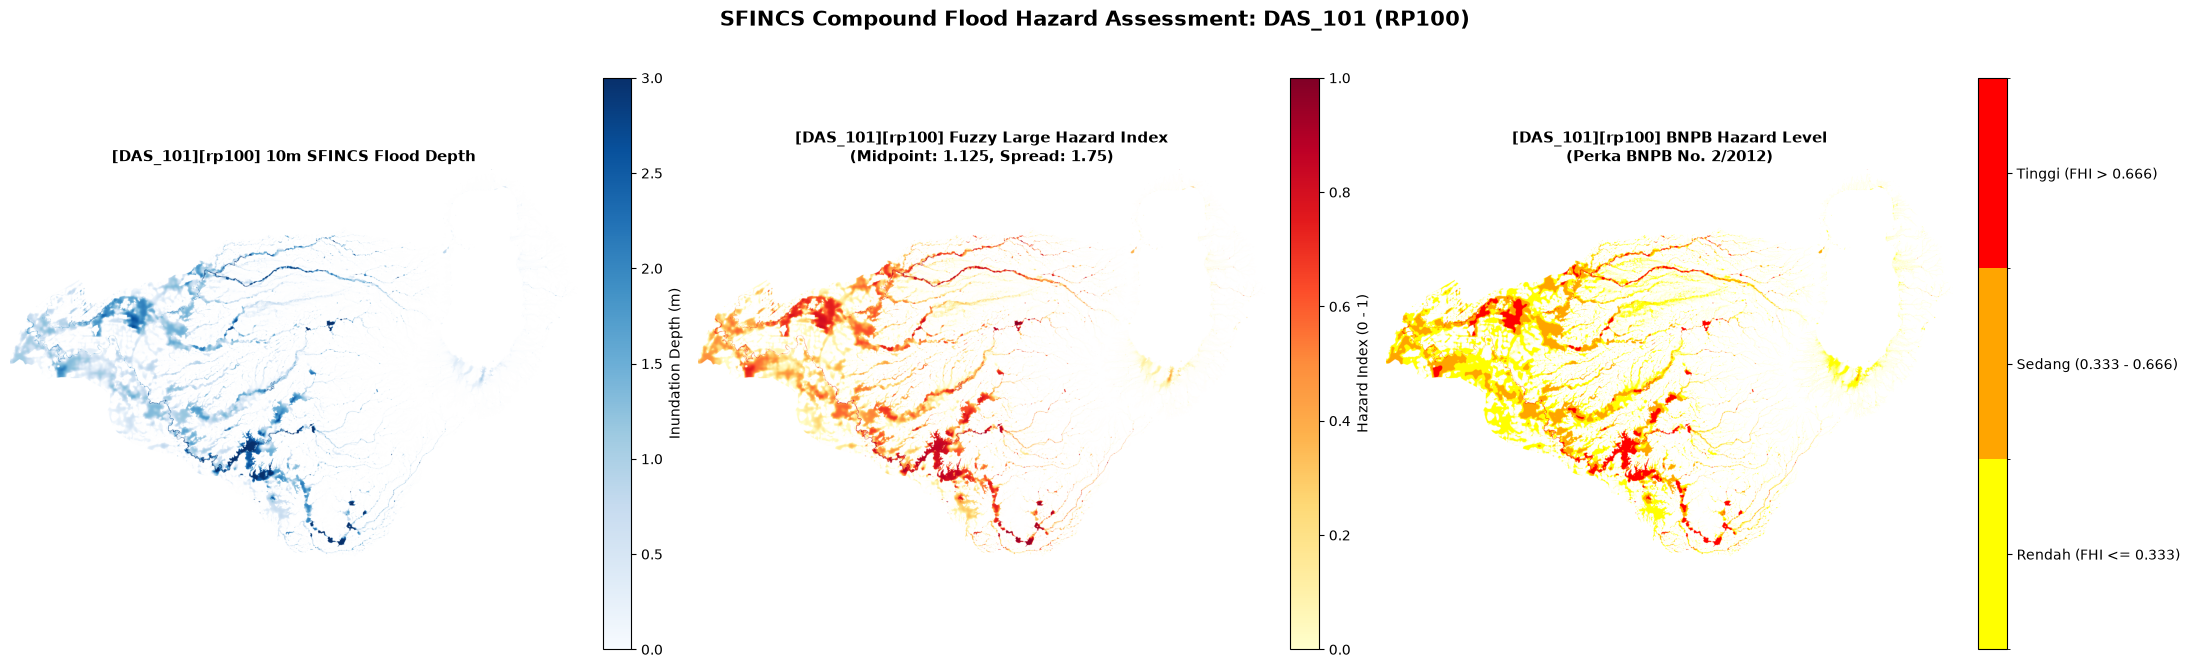

In [7]:
import matplotlib.pyplot as plt
from matplotlib.colors import ListedColormap, BoundaryNorm
import rasterio
import numpy as np
from pathlib import Path

# Select which completed run to inspect (defaults to first in list)
PLOT_DAS = SELECTED_CLUSTERS[0]
PLOT_RP = SELECTED_RPS[0]

depth_path = Path(OUTPUT_MAPS_DIR) / PLOT_DAS / PLOT_RP / "flood_depth_10m.tif"
fhi_path = Path(OUTPUT_MAPS_DIR) / PLOT_DAS / PLOT_RP / "flood_hazard_index.tif"
hazard_path = Path(OUTPUT_MAPS_DIR) / PLOT_DAS / PLOT_RP / "hazard_class_perka2012.tif"

if depth_path.exists():
    fig, (ax1, ax2, ax3) = plt.subplots(1, 3, figsize=(22, 7))
    
    # 1. Flood Inundation Depth Map (10m FABDEM Downscaled)
    with rasterio.open(depth_path) as src_d:
        depth_data = src_d.read(1)
        depth_masked = np.where(depth_data < 0.05, np.nan, depth_data)
        im1 = ax1.imshow(depth_masked, cmap="Blues", vmin=0, vmax=3.0)
        plt.colorbar(im1, ax=ax1, label="Inundation Depth (m)", fraction=0.046, pad=0.04)
        ax1.set_title(f"[{PLOT_DAS}][{PLOT_RP}] 10m SFINCS Flood Depth", fontsize=11, fontweight="bold")
        ax1.axis("off")
        
    # 2. Continuous Flood Hazard Index (Fuzzy Large: 0 to 1)
    if fhi_path.exists():
        with rasterio.open(fhi_path) as src_f:
            fhi_data = src_f.read(1)
            im2 = ax2.imshow(fhi_data, cmap="YlOrRd", vmin=0.0, vmax=1.0)
            plt.colorbar(im2, ax=ax2, label="Hazard Index (0 - 1)", fraction=0.046, pad=0.04)
            ax2.set_title(f"[{PLOT_DAS}][{PLOT_RP}] Fuzzy Large Hazard Index\n(Midpoint: 1.125, Spread: 1.75)", fontsize=11, fontweight="bold")
            ax2.axis("off")
            
    # 3. Perka BNPB No. 2/2012 Hazard Classification Map (Low, Medium, High)
    if hazard_path.exists():
        with rasterio.open(hazard_path) as src_h:
            hazard_data = src_h.read(1)
            hazard_masked = np.where(hazard_data == 0, np.nan, hazard_data)
            cmap_bnpb = ListedColormap(["#FFFF00", "#FFA500", "#FF0000"])  # Rendah (Yellow), Sedang (Orange), Tinggi (Red)
            norm = BoundaryNorm([0.5, 1.5, 2.5, 3.5], cmap_bnpb.N)
            im3 = ax3.imshow(hazard_masked, cmap=cmap_bnpb, norm=norm)
            cbar = plt.colorbar(im3, ax=ax3, ticks=[1, 2, 3], fraction=0.046, pad=0.04)
            cbar.ax.set_yticklabels(["Rendah (FHI <= 0.333)", "Sedang (0.333 - 0.666)", "Tinggi (FHI > 0.666)"])
            ax3.set_title(f"[{PLOT_DAS}][{PLOT_RP}] BNPB Hazard Level\n(Perka BNPB No. 2/2012)", fontsize=11, fontweight="bold")
            ax3.axis("off")
            
    plt.suptitle(f"SFINCS Compound Flood Hazard Assessment: {PLOT_DAS} ({PLOT_RP.upper()})", fontsize=15, fontweight="bold", y=0.98)
    plt.tight_layout()
    plt.show()
else:
    print(f"Output not found yet: {depth_path}. Please execute Steps 1-4 first.")


---
## 7. Step 6 — 24-Hour Flood Wave Propagation Animation

Extracts dynamic hourly water level slices ($t=1\text{h}, 2\text{h}, \dots, 24\text{h}$) from `sfincs_map.nc`, overlays transient flood depths over the terrain elevation model, and compiles a high-resolution looping animated GIF (`flood_propagation_24h.gif`).



==================== [DAS_101][rp100] GENERATING FLOOD PROPAGATION ANIMATION ====================
[DAS_101][rp100] Generating 24-hour flood propagation animation with hierarchical cartography...
[DAS_101][rp100] Fetching high-resolution satellite basemap tiles (Esri WorldImagery)...


findfont: Failed to find font weight semibold, now using 700.
findfont: Failed to find font weight semibold, now using 700.


[DAS_101][rp100] Hierarchical flood propagation animation saved: outputs_standalone\DAS_101\rp100\flood_propagation_24h.gif


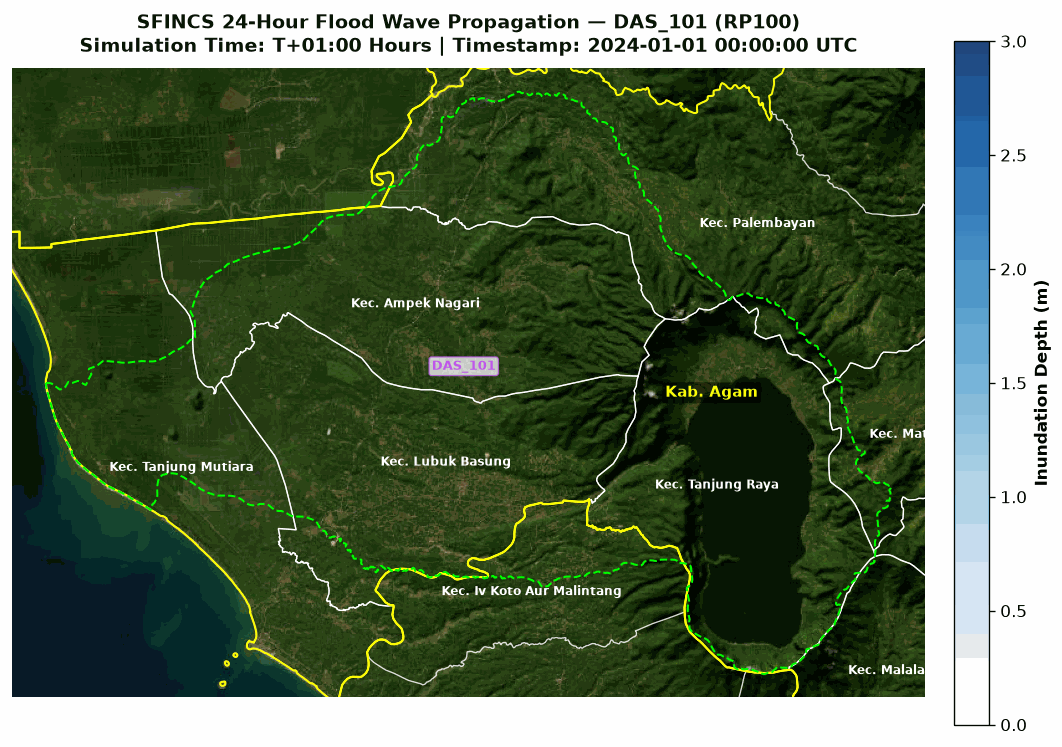

In [8]:
import sys
from pathlib import Path
if "scripts" not in sys.path:
    sys.path.insert(0, "scripts")

from IPython.display import Image, display
import importlib
import sfincs_standalone_pipeline
importlib.reload(sfincs_standalone_pipeline)
from sfincs_standalone_pipeline import create_sfincs_flood_animation

for das_id in SELECTED_CLUSTERS:
    for rp in SELECTED_RPS:
        print(f"\n==================== [{das_id}][{rp}] GENERATING FLOOD PROPAGATION ANIMATION ====================")
        anim_path = create_sfincs_flood_animation(
            das_id=das_id,
            rp=rp,
            base_model_dir=OUTPUT_MODELS_DIR,
            output_maps_dir=OUTPUT_MAPS_DIR,
            das_clusters_gpkg="data/das_clusters.gpkg",
            kecamatan_gpkg="data/boundary_kecamatan.gpkg",
            kabkot_gpkg="data/boundary_kabkot.gpkg",
            lake_gpkg="data/lake.gpkg",
            fps=2,
            hmin=0.05,
            vmax=3.0,
        )
        display(Image(filename=anim_path))
